In [2]:
words = open("names.txt", "r").read().splitlines()

Bigram Model: Only concerns 2 characters. Current char, and next char.

In [3]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(ch1, ch2)
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [4]:
sorted(b.items(), key=lambda kv: kv[1], reverse=True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [5]:
import torch

In [6]:
testTensor = torch.zeros(((3, 5)), dtype=torch.int32)
testTensor

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [7]:
testTensor[1,3] = 1
testTensor

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [8]:
N = torch.zeros(((28, 28)), dtype=torch.int32)

In [9]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)} # String TO Int
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()} # Int TO String 

In [10]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

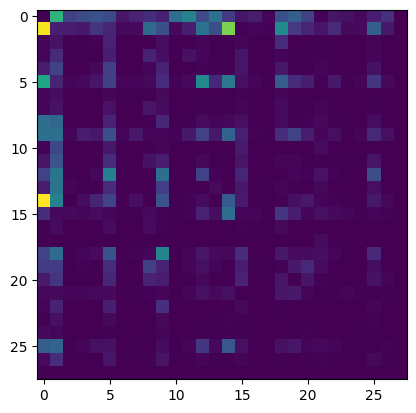

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

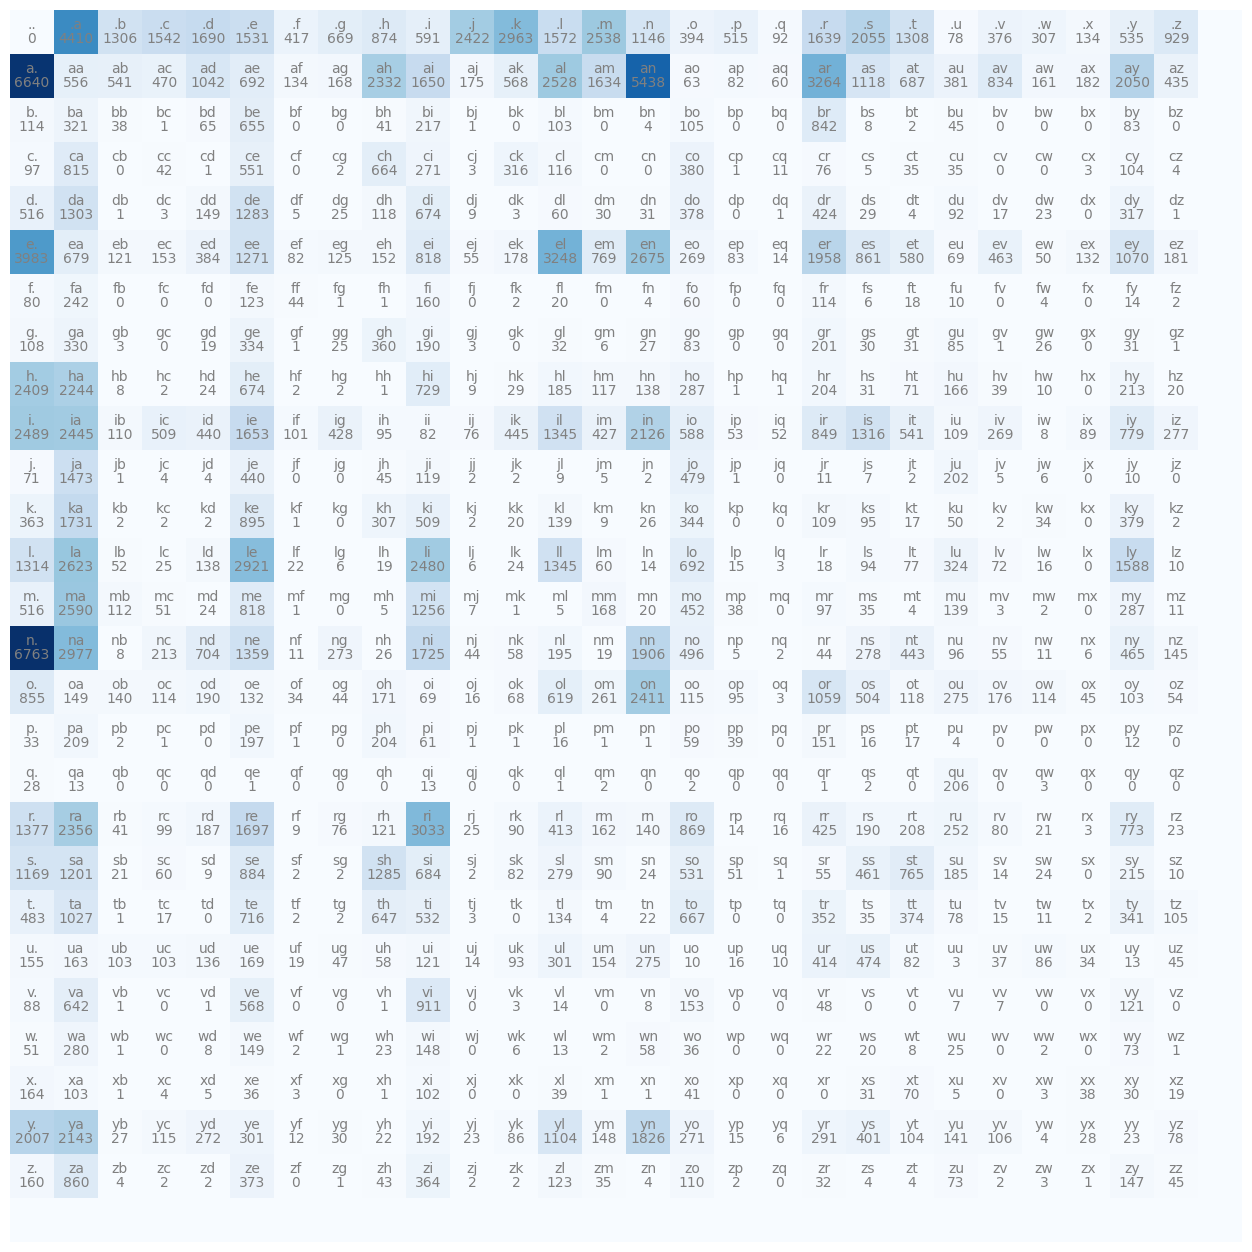

In [12]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis('off')

In [13]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290,
        0.0000])

In [14]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [15]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

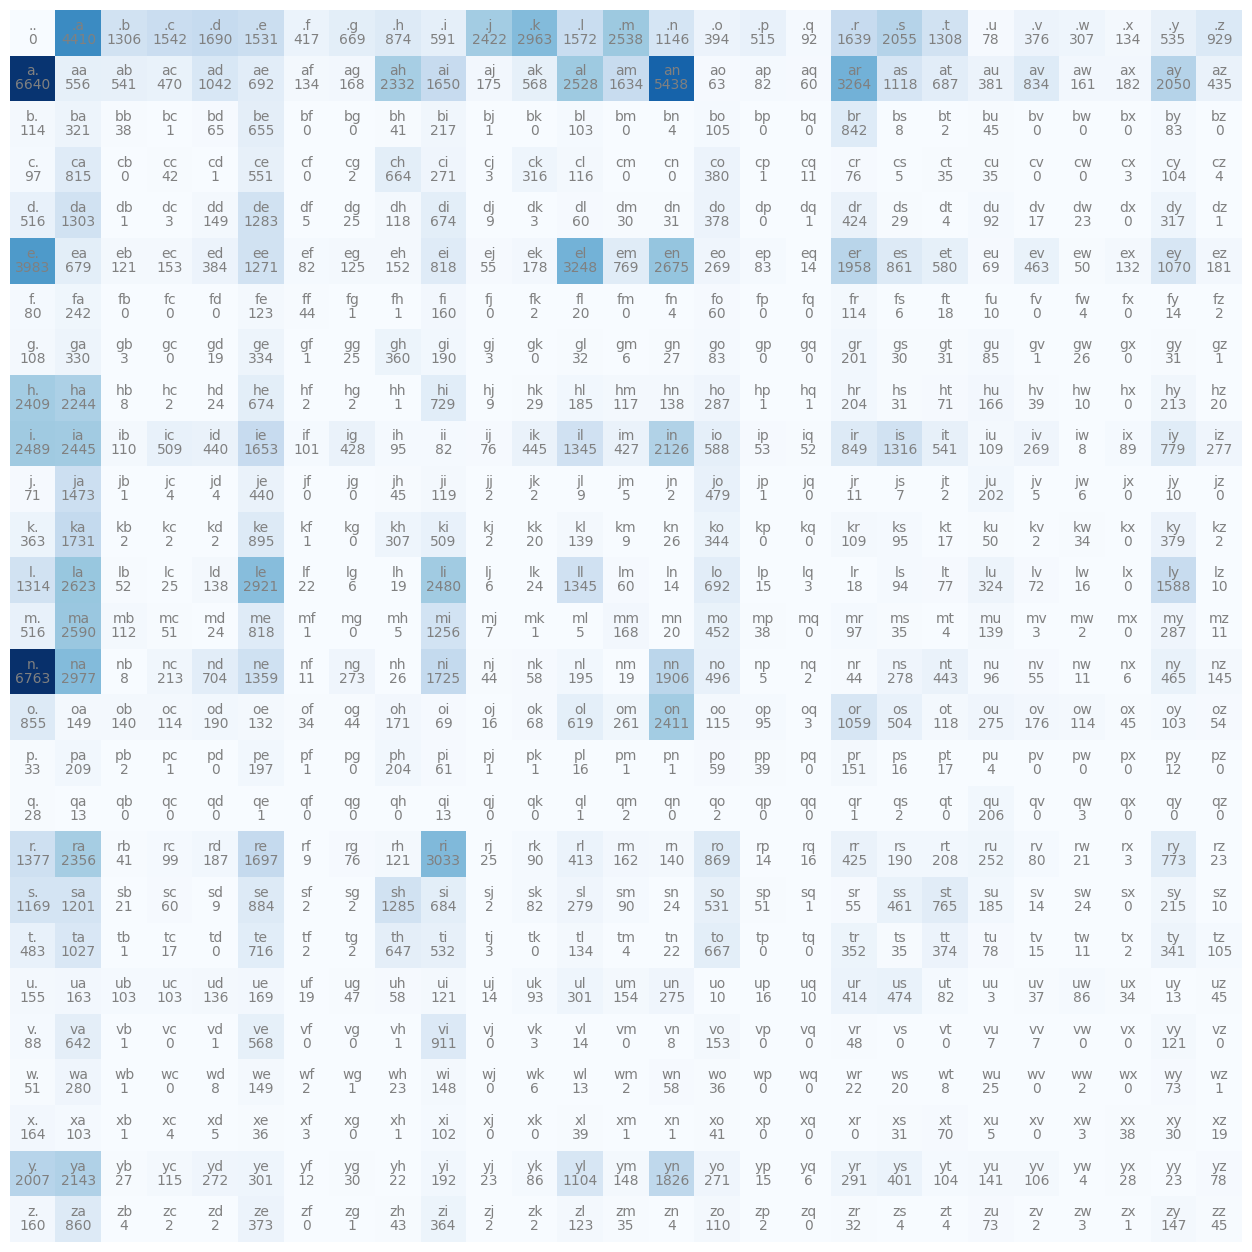

In [16]:
# Create N with the correct vocabulary size
N = torch.zeros((27, 27), dtype=torch.int32)

# Then rebuild it by counting bigrams from your training data
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis('off')

Loop:

In [17]:
P = N.float()
# P = P / P.sum(1, keepdim=True)
P /= P.sum(1, keepdim=True)

In [18]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))
    

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


We now should come up with some way of evaluating the models performance.

In [19]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        prob = P[ix1, ix2]
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(f'{ch1}{ch2}: {prob:.4f}')

.e: 0.2353
em: 0.0478
mm: 0.0377
ma: 0.0253
a.: 0.3899
.o: 0.1960
ol: 0.0123
li: 0.0780
iv: 0.1777
vi: 0.0152
ia: 0.3541
a.: 0.1381
.a: 0.1960
av: 0.1377
va: 0.0246
a.: 0.2495


For any given ch1, there are 27 possibilies for ch2, meaning that each line in the ouput above should theoretically have a probability of 1/27 (0.037, or 3.7%). If the displayed probability is more than that, that means we've learned something useful.
- The maximum likelihood is the product of all of these probabilities, and should be maximized.
- We can clearly see that the maximum likelihood would be an extremely small number, so we can work with the log likelihood instead.
- log(a*b*b) = log(a) + log(b) + log(c)

In [20]:
logLikelihood =  0.0
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        prob = P[ix1, ix2]
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        logProb = torch.log(prob)
        logLikelihood += logProb
        print(f'{ch1}{ch2}: {prob:.4f}, {logProb:.4f}')

print(f'{logLikelihood=}')

.e: 0.1960, -1.6299
em: 0.0478, -3.0408
mm: 0.0377, -3.2793
ma: 0.0253, -3.6772
a.: 0.3899, -0.9418
.o: 0.1960, -1.6299
ol: 0.0123, -4.3982
li: 0.0780, -2.5508
iv: 0.1777, -1.7278
vi: 0.0152, -4.1867
ia: 0.3541, -1.0383
a.: 0.1381, -1.9796
.a: 0.1960, -1.6299
av: 0.1377, -1.9829
va: 0.0246, -3.7045
a.: 0.2495, -1.3882
logLikelihood=tensor(-38.7856)


As the probabilities being multiplied approach  (get better), the logLikelihood approaches 0, and as they decrease towards 0, the logLikelihood approaches negative infinity. This is not ideal, as in loss functions, we want it to be such that the loss is minimized. In this case, minimizing the logLikelihood means making the predictions worse. To work around this, we can just use the negative logLikelihood (negate what we have).

In [21]:
logLikelihood =  0.0
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        prob = P[ix1, ix2]
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        logProb = torch.log(prob)
        logLikelihood += logProb
        print(f'{ch1}{ch2}: {prob:.4f}, {logProb:.4f}')

print(f'{logLikelihood=}')
nll = -logLikelihood
print(f'{nll=}')

.e: 0.1960, -1.6299
em: 0.0478, -3.0408
mm: 0.0377, -3.2793
ma: 0.0253, -3.6772
a.: 0.3899, -0.9418
.o: 0.1960, -1.6299
ol: 0.0123, -4.3982
li: 0.0780, -2.5508
iv: 0.1777, -1.7278
vi: 0.0152, -4.1867
ia: 0.3541, -1.0383
a.: 0.1381, -1.9796
.a: 0.1960, -1.6299
av: 0.1377, -1.9829
va: 0.0246, -3.7045
a.: 0.2495, -1.3882
logLikelihood=tensor(-38.7856)
nll=tensor(38.7856)


There is another small problem. Say there are names such as "Andrejq". If I run for w in ["andrejq"], the result would be infinite, as the probability of jq is 0, since that order and combination did not occur in the dataset. To counteract this, we can do something called dataset smoothing, by adding 1 to the count of every combination. That way, zero probability combinations get a probability (though extremely small, would break the program with a name like andrejq), and very slightly increasing the counts of nonzero combinations in parralel.

In [22]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)

logLikelihood =  0.0
# for w in words[:3]:
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        prob = P[ix1, ix2]
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        logProb = torch.log(prob)
        logLikelihood += logProb
        print(f'{ch1}{ch2}: {prob:.4f}, {logProb:.4f}')

print(f'{logLikelihood=}')
nll = -logLikelihood
print(f'{nll=}')

.a: 0.1958, -1.6305
an: 0.1376, -1.9835
nd: 0.1604, -1.8302
dr: 0.0384, -3.2594
re: 0.0770, -2.5646
ej: 0.1334, -2.0143
jq: 0.0027, -5.9004
q.: 0.0003, -7.9817
logLikelihood=tensor(-27.1646)
nll=tensor(27.1646)


Now, a name like andrejq, if fed into the model will not return an infinite nll

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

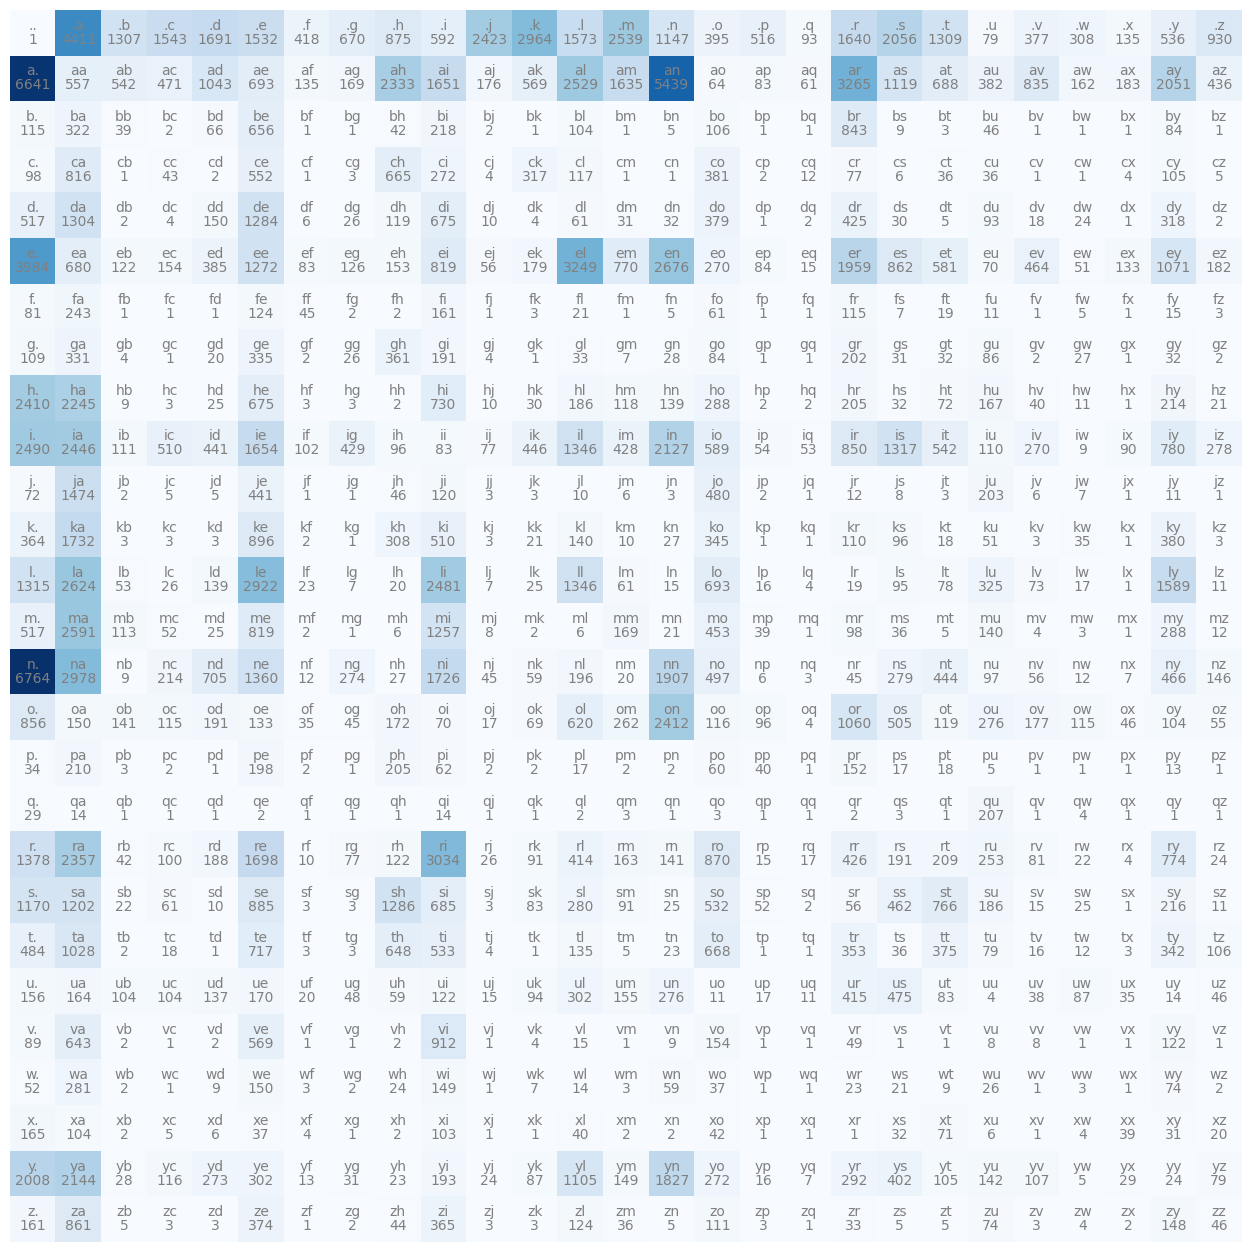

In [23]:
# Create N with the correct vocabulary size
N = torch.zeros((27, 27), dtype=torch.int32)
N = N+1
# The probability chart below shows each probability, imputing 1s for previous 0s, and adding 1 to preexistent counts

# Then rebuild it by counting bigrams from your training data
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis('off')

Now that we've clarified the loss function, and the bigram model, lets figure out the neural network, and how to implement it.

In [24]:
# Define training set of bigrams (x, y)

xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
        print(ch1, ch2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)


. e
e m
m m
m a
a .


In [25]:
xs

tensor([ 0,  5, 13, 13,  1])

In [26]:
ys

tensor([ 5, 13, 13,  1,  0])

For the word emma, there are 5 bigrams as shown above. We need to configure the neural network to predict that 5 has a high probability when 0 is the first character in a bigram, 13 has a high probability when 5 is the first character in a bigram, and so on.

Lets think about how we'd feed the data into a neural network. It doenst make sense to just have each neuron output a simple integer value and have these integers multiply amongst themselves. Instead, we can preprocess the data with one-hot-encoding, to take advantage of different dimensions of vectors.
- To one-hot-encode 5, the vector would be [0, 0, 0, 0, 0, 5, 0, ..., n]

In [27]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() # If feeding something into a neural network, make sure its dtype is float
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [28]:
xenc.shape

torch.Size([5, 27])

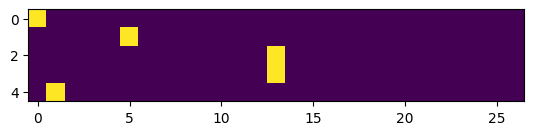

In [29]:
plt.imshow(xenc)

In [30]:
# Initialize weights
W = torch.randn((27, 27))

# Cross product  between inputs and weights
xenc @ W

tensor([[-1.5129,  0.3721, -1.5210,  1.9011, -0.2639,  2.8321, -0.1421,  0.1714,
          1.2553,  0.1260,  0.1223, -0.4611,  0.5257,  2.2951,  0.2347,  1.5414,
          0.5935,  1.6474, -2.1958,  0.3095,  0.7843, -1.2646, -0.9386, -2.1962,
          0.9135,  1.1771, -0.8422],
        [ 0.0511,  1.6724,  0.2727,  0.7780, -0.3516, -1.4194, -0.1866, -1.8704,
         -2.7864, -0.6092,  0.3062, -0.6828,  0.5534,  1.0473,  1.8430, -1.0292,
         -0.5861, -1.7046,  0.3825, -1.5192, -1.9364, -0.1174,  1.1005,  1.6534,
         -0.7648,  0.3981, -0.9397],
        [-0.9426,  0.1408,  0.3439,  0.1638,  0.9625,  0.1721,  3.2726, -0.8153,
          0.8485,  0.5261, -0.6213, -0.4550,  1.0905,  0.3553, -0.8288, -0.8181,
         -0.1579,  0.1159,  0.3045,  0.8200,  0.0655,  0.5545,  0.6398, -0.6630,
         -0.4310, -1.1855, -0.3059],
        [-0.9426,  0.1408,  0.3439,  0.1638,  0.9625,  0.1721,  3.2726, -0.8153,
          0.8485,  0.5261, -0.6213, -0.4550,  1.0905,  0.3553, -0.8288, -0.8181

In [31]:
# Interpret xenc @ W as a (log) probability distribution
# To get probabilities, exponentiate everything
# Logits are log-counts.
logits = (xenc @ W)
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs

tensor([[0.0031, 0.0207, 0.0031, 0.0957, 0.0110, 0.2427, 0.0124, 0.0170, 0.0502,
         0.0162, 0.0162, 0.0090, 0.0242, 0.1419, 0.0181, 0.0668, 0.0259, 0.0742,
         0.0016, 0.0195, 0.0313, 0.0040, 0.0056, 0.0016, 0.0356, 0.0464, 0.0062],
        [0.0266, 0.1346, 0.0332, 0.0550, 0.0178, 0.0061, 0.0210, 0.0039, 0.0016,
         0.0137, 0.0343, 0.0128, 0.0440, 0.0720, 0.1596, 0.0090, 0.0141, 0.0046,
         0.0371, 0.0055, 0.0036, 0.0225, 0.0760, 0.1321, 0.0118, 0.0376, 0.0099],
        [0.0067, 0.0199, 0.0244, 0.0204, 0.0453, 0.0206, 0.4568, 0.0077, 0.0405,
         0.0293, 0.0093, 0.0110, 0.0515, 0.0247, 0.0076, 0.0076, 0.0148, 0.0194,
         0.0235, 0.0393, 0.0185, 0.0301, 0.0328, 0.0089, 0.0113, 0.0053, 0.0128],
        [0.0067, 0.0199, 0.0244, 0.0204, 0.0453, 0.0206, 0.4568, 0.0077, 0.0405,
         0.0293, 0.0093, 0.0110, 0.0515, 0.0247, 0.0076, 0.0076, 0.0148, 0.0194,
         0.0235, 0.0393, 0.0185, 0.0301, 0.0328, 0.0089, 0.0113, 0.0053, 0.0128],
        [0.0779, 0.0105,

Process:
1. Take a word(for eg emma)
2. Get the numerical representation (in this case, (0, 5, 13, 13, 1, 0))
3. One-hot-encode the numerical representation (make it shape (5, 27))
4. Cross product the numerical representation with the weights in the first layer of the neural network to get the logits.
5. Exponentiate the result, and then create a probability distribution from it. This is called softmaxxing.
    - Softmaxxing can be put after any layer in a neural network to make a new probability distribution before the next layer begins operation.

In [32]:
# Forward pass

logits = (xenc @ W)
counts = logits.exp() # Softmax part 1
probs = counts / counts.sum(1, keepdim=True) # Softmax part 2

# Notice that all operation in the forward pass are differentiable. This means that we can backpropagate through it.

In [36]:
# DEMO

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)
xenc = F.one_hot(xs, num_classes=27).float()
logits = (xenc @ W)
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)

nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item() # input character index
    y = ys[i].item() # label character index
    print('----------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('==========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

----------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.012286250479519367
log likelihood: -4.3992743492126465
negative log likelihood: 4.3992743492126465
----------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct charac

Full model walkthrough

In [43]:
# Setup
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)
xenc = F.one_hot(xs, num_classes=27).float()
logits = (xenc @ W)
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)


In [57]:
# Forward pass
    # Calculate probabilities (same as the .data from micrograd)
logits = (xenc @ W)
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
    # Calculate loss
# loss = -probs[torch.arange(5), ys].log().mean()
loss = -probs[torch.arange(len(xs)), ys].log().mean()

In [52]:
# Backward pass
    # Reset all gradients to 0
W.grad = None
    # Backpropagate
loss.backward()

In [40]:
# W.grad

In [56]:
# Gradient descent
W.data += -0.1 * W.grad

In [58]:
# After running a forward pass to calculate weights, a backward pass to compute their gradients/influence on the loss, and gradient descent to update the weights, we can run another forward pass to see if the loss has decreased:
print(loss.item())

3.7091331481933594


All together:

In [63]:
# create the dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [64]:
# gradient descent
for k in range(100):
    
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean()
    print(loss.item())
    
    # backward pass
    W.grad = None # set to zero the gradient
    loss.backward()
    
    # update
    W.data += -50 * W.grad

3.758953809738159
3.371100664138794
3.1540427207946777
3.020373821258545
2.927711248397827
2.8604023456573486
2.8097290992736816
2.7701022624969482
2.7380728721618652
2.711496591567993
2.6890032291412354
2.6696887016296387
2.6529300212860107
2.638277769088745
2.6253879070281982
2.613990545272827
2.60386323928833
2.5948216915130615
2.5867116451263428
2.579403877258301
2.572789192199707
2.5667762756347656
2.5612878799438477
2.5562589168548584
2.551633596420288
2.547366142272949
2.5434155464172363
2.5397486686706543
2.536336660385132
2.5331544876098633
2.5301806926727295
2.5273969173431396
2.5247862339019775
2.522334337234497
2.520029067993164
2.517857789993286
2.515810966491699
2.513878345489502
2.512052059173584
2.510324001312256
2.5086867809295654
2.5071346759796143
2.5056614875793457
2.5042612552642822
2.502929210662842
2.5016608238220215
2.5004520416259766
2.4992990493774414
2.498197317123413
2.4971446990966797
2.4961376190185547
2.495173215866089
2.4942495822906494
2.493363380432129

In [65]:
#  Sampling from the trained model

g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    
    out = []
    ix = 0
    while True:
        
        # -----------
        # BEFORE:
        p = P[ix]
        # -----------
        # NOW:
#       xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
#       logits = xenc @ W # predict log-counts
#       counts = logits.exp() # counts, equivalent to N
#       p = counts / counts.sum(1, keepdims=True) # probabilities for next character
        # -----------
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
